# Multi-Dimensional Domain Modeling, Advanced Meta-Ensembles & Explainable AI (SHAP)
### Olist Brazilian E-Commerce MSc Data Science Dissertation

## Project Overview:
This notebook presents the main empirical analysis of the thesis, using a multi-dimensional predictive modeling framework that carefully avoids target leakage.


1. **Multi-Table Feature Engineering (4 Key Dimensions)**:
   - *Satisfaction & Sentiment*: Review Scores, Bad Review Ratios.
   - *Logistics & Delivery Friction*: Actual Delivery Days, Delivery Delays vs. Estimated Date, Interstate Cross-Region Orders.
   - *Basket Economics*: Monetary Spend, Average Order Value, Average Item Price, Freight Cost & Freight Ratio.
   - *Payment Dynamics*: Installments, Payment Method Share (Credit Card vs. Boleto).
2. **Advanced Ensemble Learning**:
   - Benchmark **Logistic Regression**, **Random Forest**, **XGBoost**, **Soft Voting Ensemble**, and **Stacking Meta-Ensemble**.
3. **Explainable AI (XAI) with SHAP**:
   - Global Feature Attribution via **SHAP Summary Beeswarm Plot**.
   - Individual Customer Case Study via **SHAP Waterfall Plot**.
4. **Prescriptive Action Matrix**:
   - Segmenting customers into Risk vs. Value Quadrants for targeted marketing intervention.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    f1_score,
    accuracy_score
)

# ---------------------------------------------------------
# 1. Load Raw Multi-Table Relational Data
# ---------------------------------------------------------
raw_dir = os.path.join("..", "Data", "Raw") if os.path.exists(os.path.join("..", "Data", "Raw")) else os.path.join("Data", "Raw")
proc_dir = os.path.join("..", "Data", "Processed") if os.path.exists(os.path.join("..", "Data", "Processed")) else os.path.join("Data", "Processed")

df_master = pd.read_csv(os.path.join(proc_dir, "df_master.csv"))
df_reviews = pd.read_csv(os.path.join(raw_dir, "olist_order_reviews_dataset.csv"))
df_sellers = pd.read_csv(os.path.join(raw_dir, "olist_sellers_dataset.csv"))
df_products = pd.read_csv(os.path.join(raw_dir, "olist_products_dataset.csv"))

# Date conversions
for c in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    df_master[c] = pd.to_datetime(df_master[c])

# Delivery Days & Latency
df_master["actual_delivery_days"] = (df_master["order_delivered_customer_date"] - df_master["order_purchase_timestamp"]).dt.total_seconds() / 86400.0
df_master["delay_days"] = (df_master["order_delivered_customer_date"] - df_master["order_estimated_delivery_date"]).dt.total_seconds() / 86400.0
df_master["is_delayed"] = (df_master["delay_days"] > 0).astype(int)

# Merge auxiliary tables
reviews_clean = df_reviews.drop_duplicates(subset=["order_id"])[["order_id", "review_score"]]
sellers_clean = df_sellers.drop_duplicates(subset=["seller_id"])[["seller_id", "seller_state"]]
products_clean = df_products.drop_duplicates(subset=["product_id"])[["product_id", "product_weight_g"]]

df_merged = (
    df_master
    .merge(reviews_clean, on="order_id", how="left")
    .merge(sellers_clean, on="seller_id", how="left")
    .merge(products_clean, on="product_id", how="left")
)
df_merged["is_same_state"] = (df_merged["customer_state"] == df_merged["seller_state"]).astype(int)

print(f"Unified Relational Rows: {len(df_merged):,}")

Unified Relational Rows: 115,035


## 2. Multi-Dimensional Customer Feature Engineering

In [2]:
# Target Definition (6-month inactivity cutoff)
max_date = df_merged["order_purchase_timestamp"].max()
cutoff_date = max_date - pd.DateOffset(months=6)
last_purchase = df_merged.groupby("customer_unique_id")["order_purchase_timestamp"].max()
y = (last_purchase < cutoff_date).astype(int)

# Customer-Level Feature Aggregations
X = df_merged.groupby("customer_unique_id").agg(
    # 1. Satisfaction & Reviews
    Avg_Review_Score=("review_score", "mean"),
    Bad_Review_Ratio=("review_score", lambda x: (x <= 2).mean()),
    # 2. Logistics & Delivery Latency
    Avg_Delivery_Days=("actual_delivery_days", "mean"),
    Delay_Ratio=("is_delayed", "mean"),
    Avg_Delay_Days=("delay_days", lambda x: np.maximum(0, x).mean()),
    Same_State_Ratio=("is_same_state", "mean"),
    Avg_Product_Weight=("product_weight_g", "mean"),
    # 3. Basket Economics & Freight
    Monetary=("payment_value", "sum"),
    Avg_Item_Price=("price", "mean"),
    Total_Freight=("freight_value", "sum"),
    Avg_Freight=("freight_value", "mean"),
    # 4. Payment Structure
    Frequency=("order_id", "nunique"),
    Total_Items=("order_item_id", "count"),
    Avg_Installments=("payment_installments", "mean"),
    Credit_Card_Ratio=("payment_type", lambda x: (x == "credit_card").mean()),
    Boleto_Ratio=("payment_type", lambda x: (x == "boleto").mean())
)

X["Avg_Order_Value"] = X["Monetary"] / X["Frequency"]
X["Freight_Ratio"] = X["Total_Freight"] / (X["Monetary"] + 1e-5)
X = X.fillna(X.median()).loc[y.index]

print(f"Feature Matrix Shape: {X.shape}")
display(X.head())

Feature Matrix Shape: (93357, 18)


,Avg_Review_Score,Bad_Review_Ratio,Avg_Delivery_Days,Delay_Ratio,Avg_Delay_Days,Same_State_Ratio,Avg_Product_Weight,Monetary,Avg_Item_Price,Total_Freight,Avg_Freight,Frequency,Total_Items,Avg_Installments,Credit_Card_Ratio,Boleto_Ratio,Avg_Order_Value,Freight_Ratio
customer_unique_id,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,5.0,0.0,6.411227,0.0,0.0,1.0,1500.0,141.90,129.90,12.00,12.00,1,1,8.0,1.0,0.0,141.90,0.084567
0000b849f77a49e4a4ce2b2a4ca5be3f,4.0,0.0,3.285590,0.0,0.0,1.0,375.0,27.19,18.90,8.29,8.29,1,1,1.0,1.0,0.0,27.19,0.304891
0000f46a3911fa3c0805444483337064,3.0,0.0,25.731759,0.0,0.0,0.0,1500.0,86.22,69.00,17.22,17.22,1,1,8.0,1.0,0.0,86.22,0.199722
0000f6ccb0745a6a4b88665a16c9f078,4.0,0.0,20.037083,0.0,0.0,0.0,150.0,43.62,25.99,17.63,17.63,1,1,4.0,1.0,0.0,43.62,0.404172
0004aac84e0df4da2b147fca70cf8255,5.0,0.0,13.141134,0.0,0.0,1.0,6050.0,196.89,180.00,16.89,16.89,1,1,6.0,1.0,0.0,196.89,0.085784


## 3. Stratified Split & Model Ensembling (Stacking & Voting)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Base Estimators
rf_model = RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42, eval_metric="logloss")
lr_model = ImbPipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=1000, random_state=42))])

# Meta-Ensembles
voting_model = VotingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    voting="soft",
    n_jobs=-1
)

stacking_model = StackingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    final_estimator=LogisticRegression(random_state=42),
    cv=3,
    n_jobs=-1
)

all_models = {
    "Logistic Regression": lr_model,
    "XGBoost Classifier": xgb_model,
    "Random Forest Classifier": rf_model,
    "Soft Voting Ensemble": voting_model,
    "Stacking Meta-Ensemble": stacking_model
}

results_list = []
prob_dict = {}

for name, clf in all_models.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:, 1]
    prob_dict[name] = probs
    
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

benchmark_df = pd.DataFrame(results_list)
display(benchmark_df.sort_values("ROC-AUC", ascending=False))

Training Logistic Regression...
Training XGBoost Classifier...
Training Random Forest Classifier...
Training Soft Voting Ensemble...
Training Stacking Meta-Ensemble...


,Model,Accuracy,F1-Score,ROC-AUC
4,Stacking Meta-Ensemble,0.846776,0.873446,0.921159
2,Random Forest Classifier,0.844527,0.875070,0.919876
3,Soft Voting Ensemble,0.833066,0.866286,0.909155
1,XGBoost Classifier,0.809126,0.847275,0.885073
0,Logistic Regression,0.654938,0.742846,0.673763


## 4. Multi-Model ROC Comparison Visual

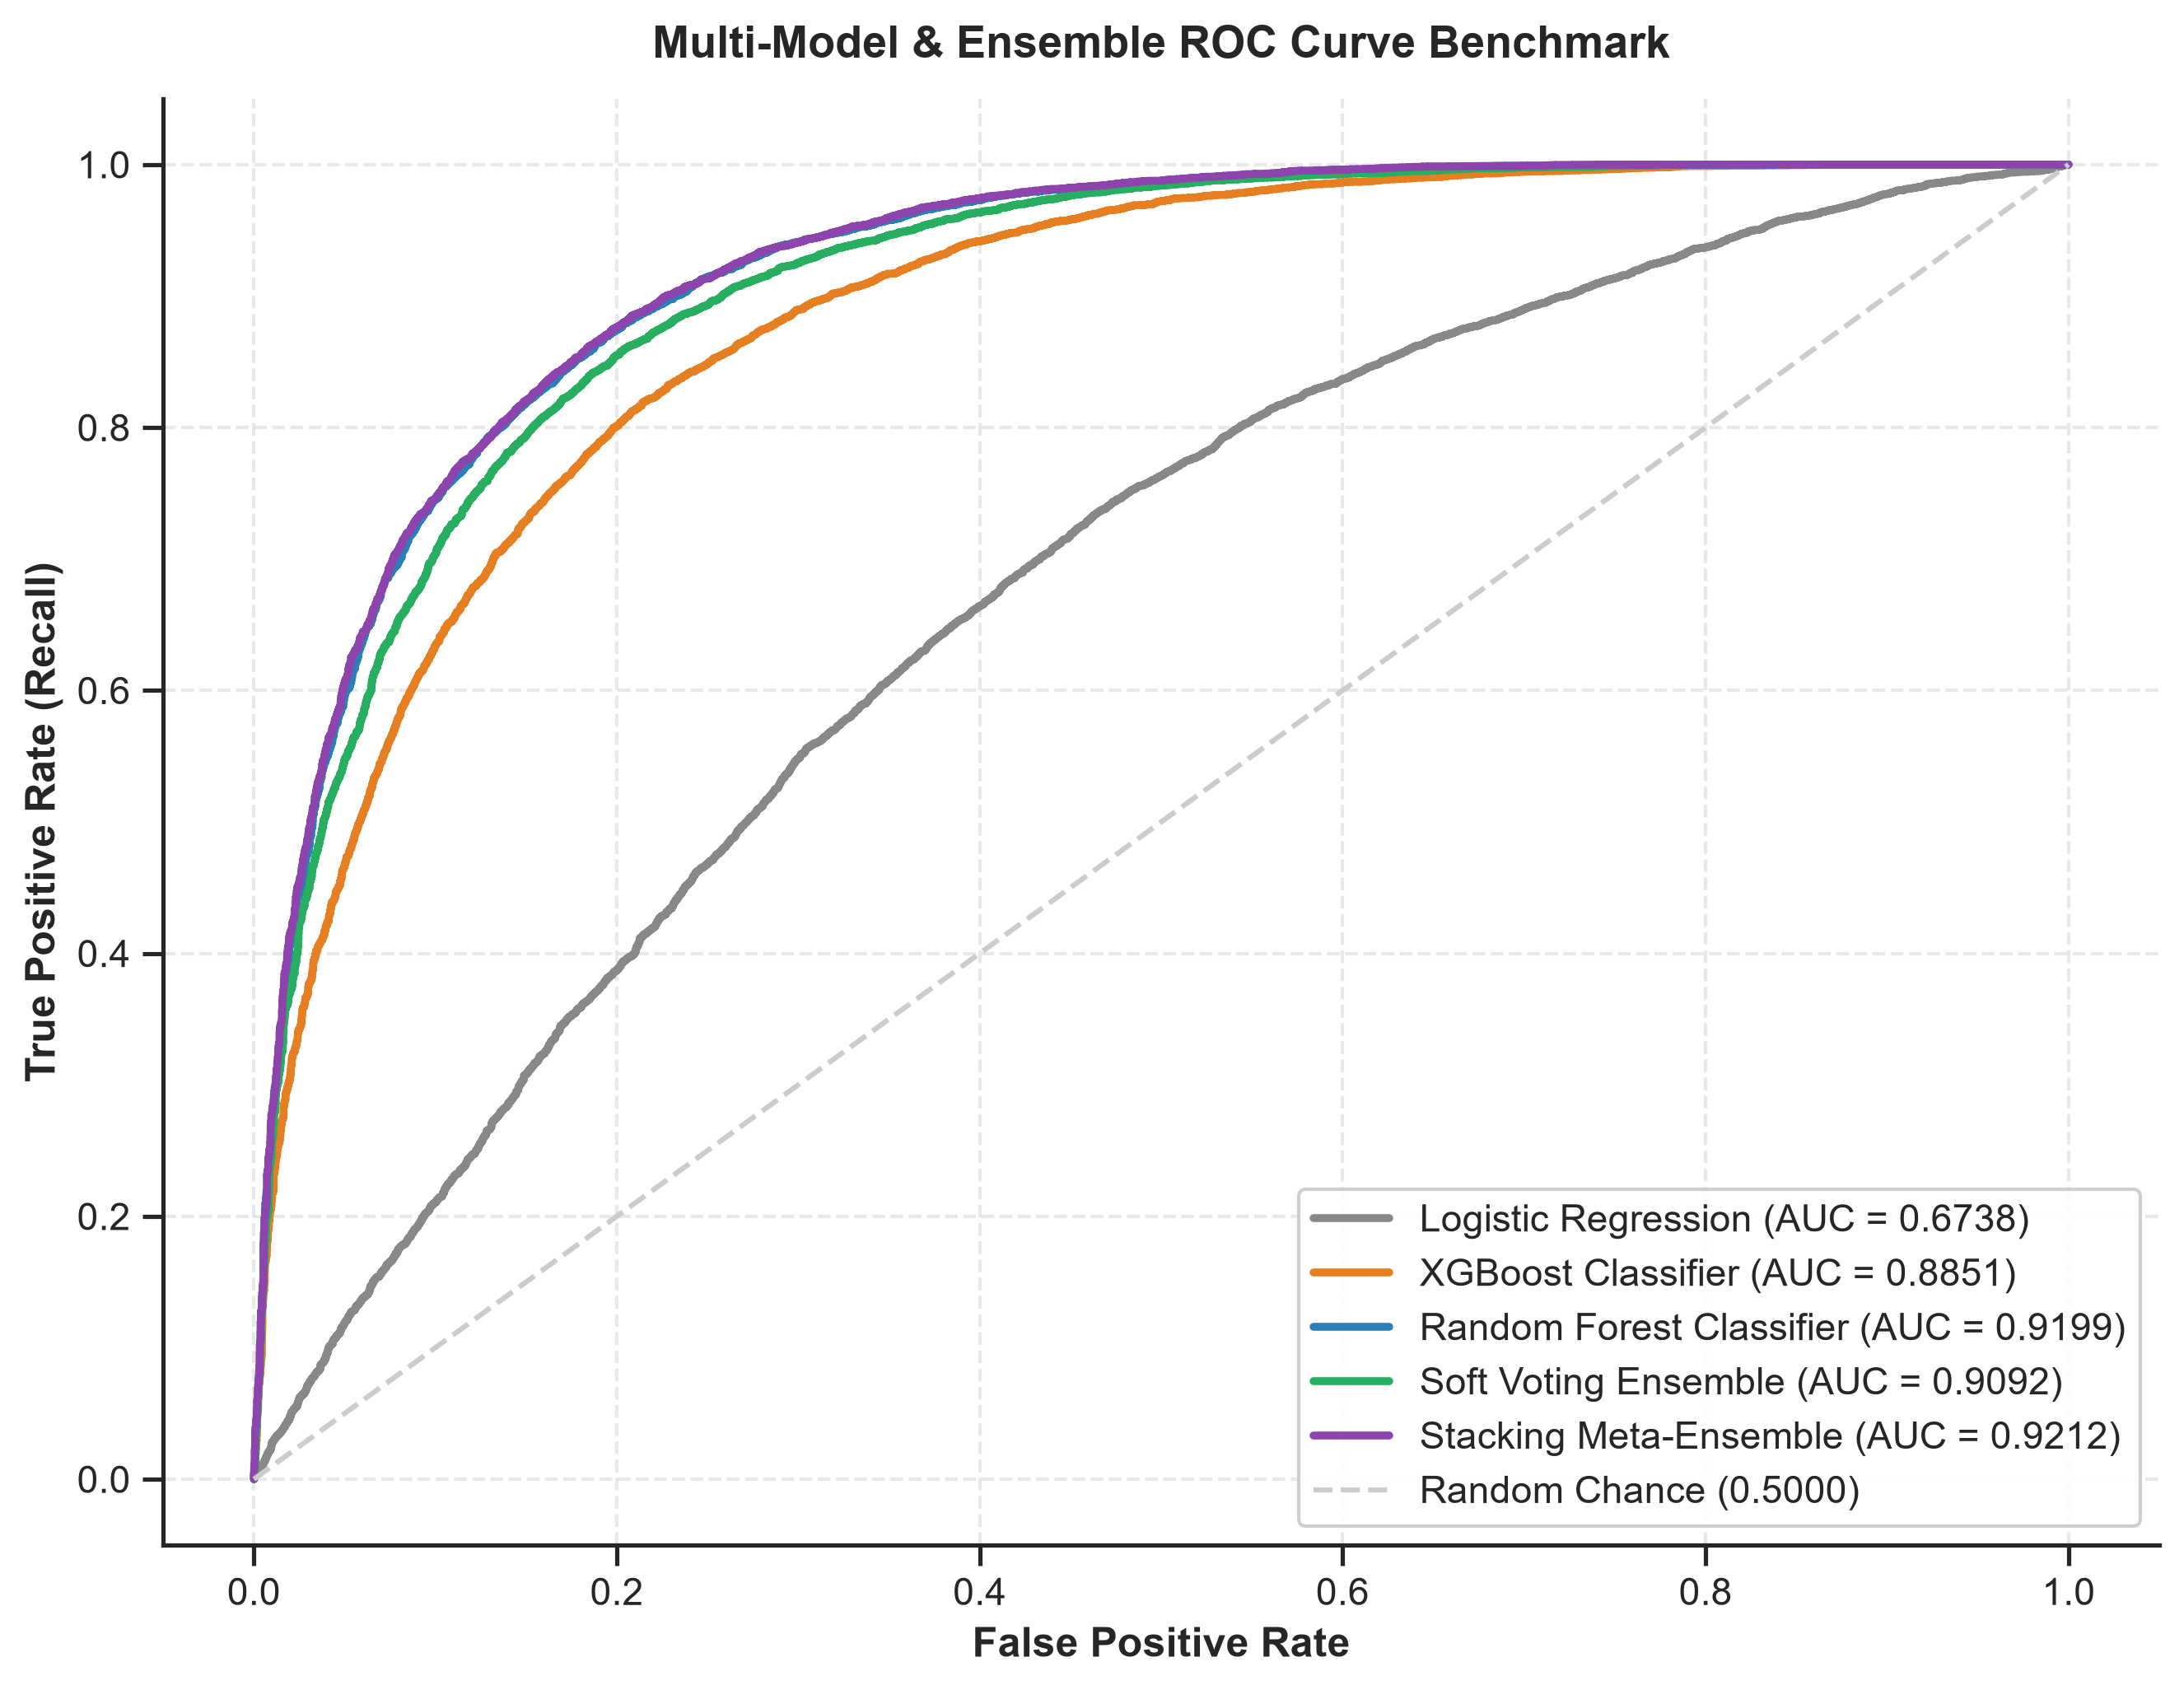

In [4]:
sns.set_theme(style="ticks", font="sans-serif")
plt.figure(figsize=(9, 7), dpi=300)

palette = {
    "Logistic Regression": "#888888",
    "XGBoost Classifier": "#E67E22",
    "Random Forest Classifier": "#2980B9",
    "Soft Voting Ensemble": "#27AE60",
    "Stacking Meta-Ensemble": "#8E44AD"
}

for name, probs in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=palette[name], linewidth=2.3, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], color="#CCCCCC", linestyle="--", label="Random Chance (0.5000)")
plt.title("Multi-Model & Ensemble ROC Curve Benchmark", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("False Positive Rate", fontweight="bold")
plt.ylabel("True Positive Rate (Recall)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(loc="lower right", frameon=True, framealpha=0.94)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## 5. Explainable AI (SHAP Analysis)

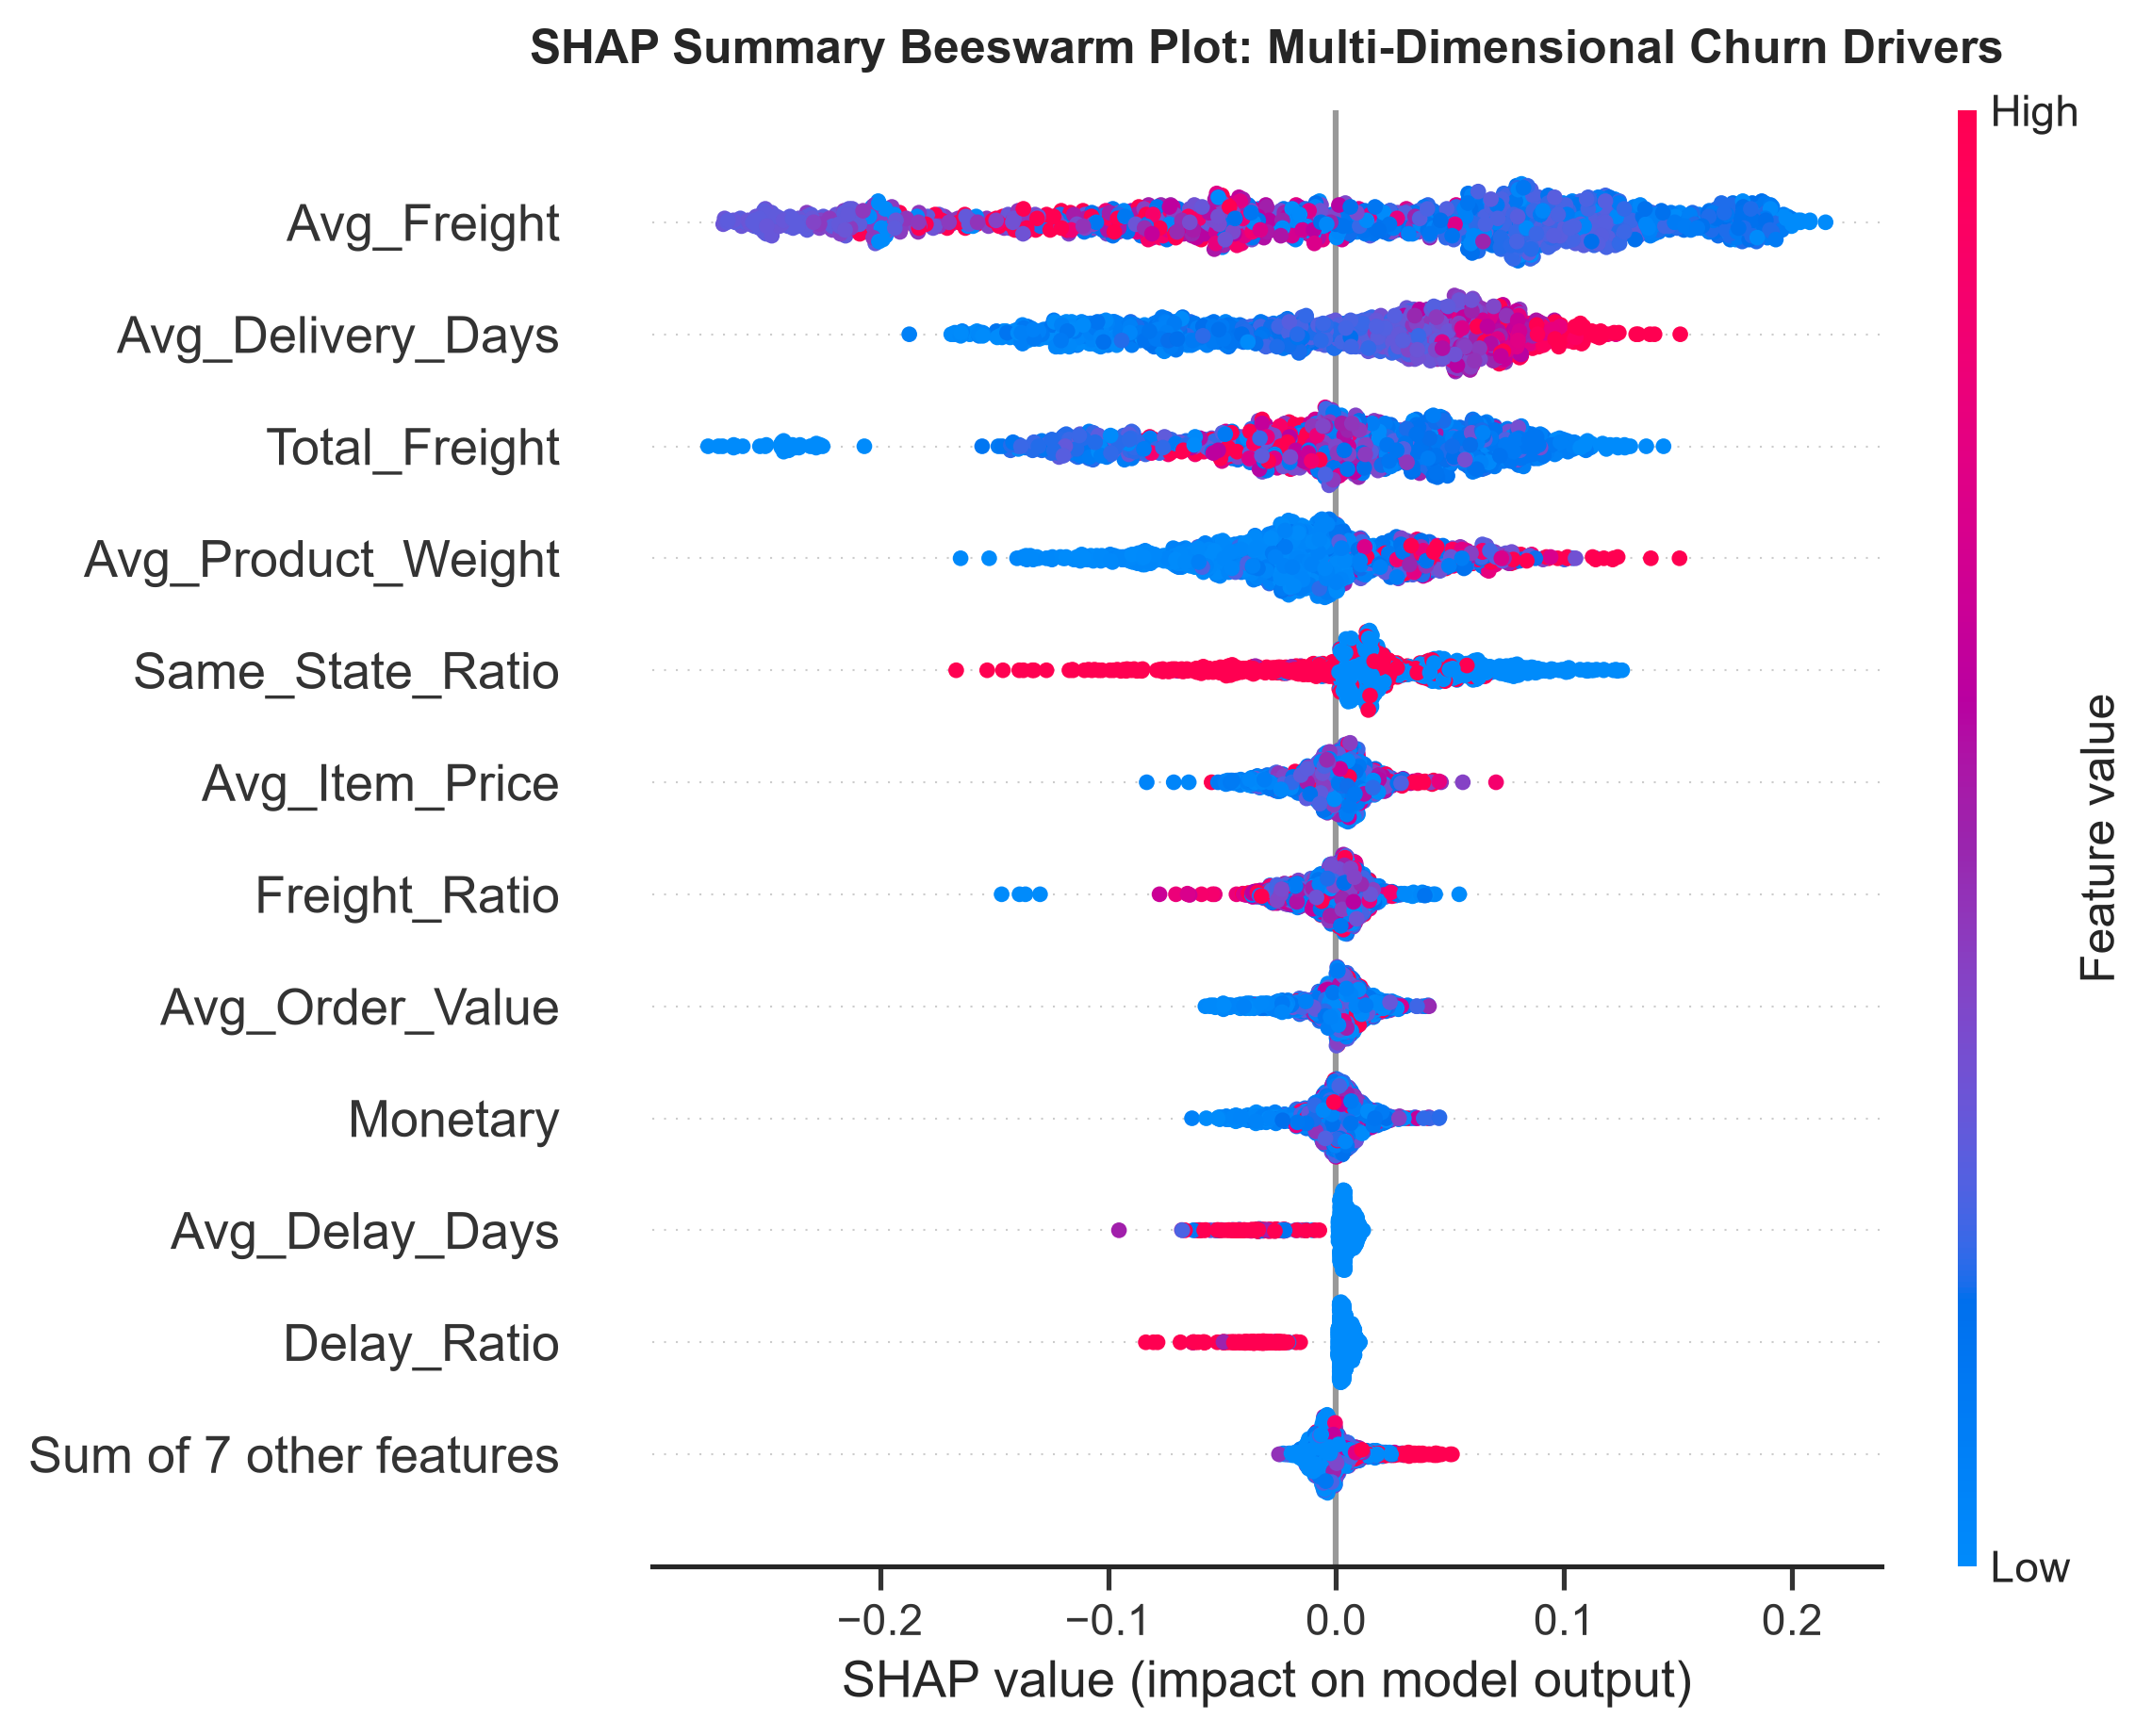

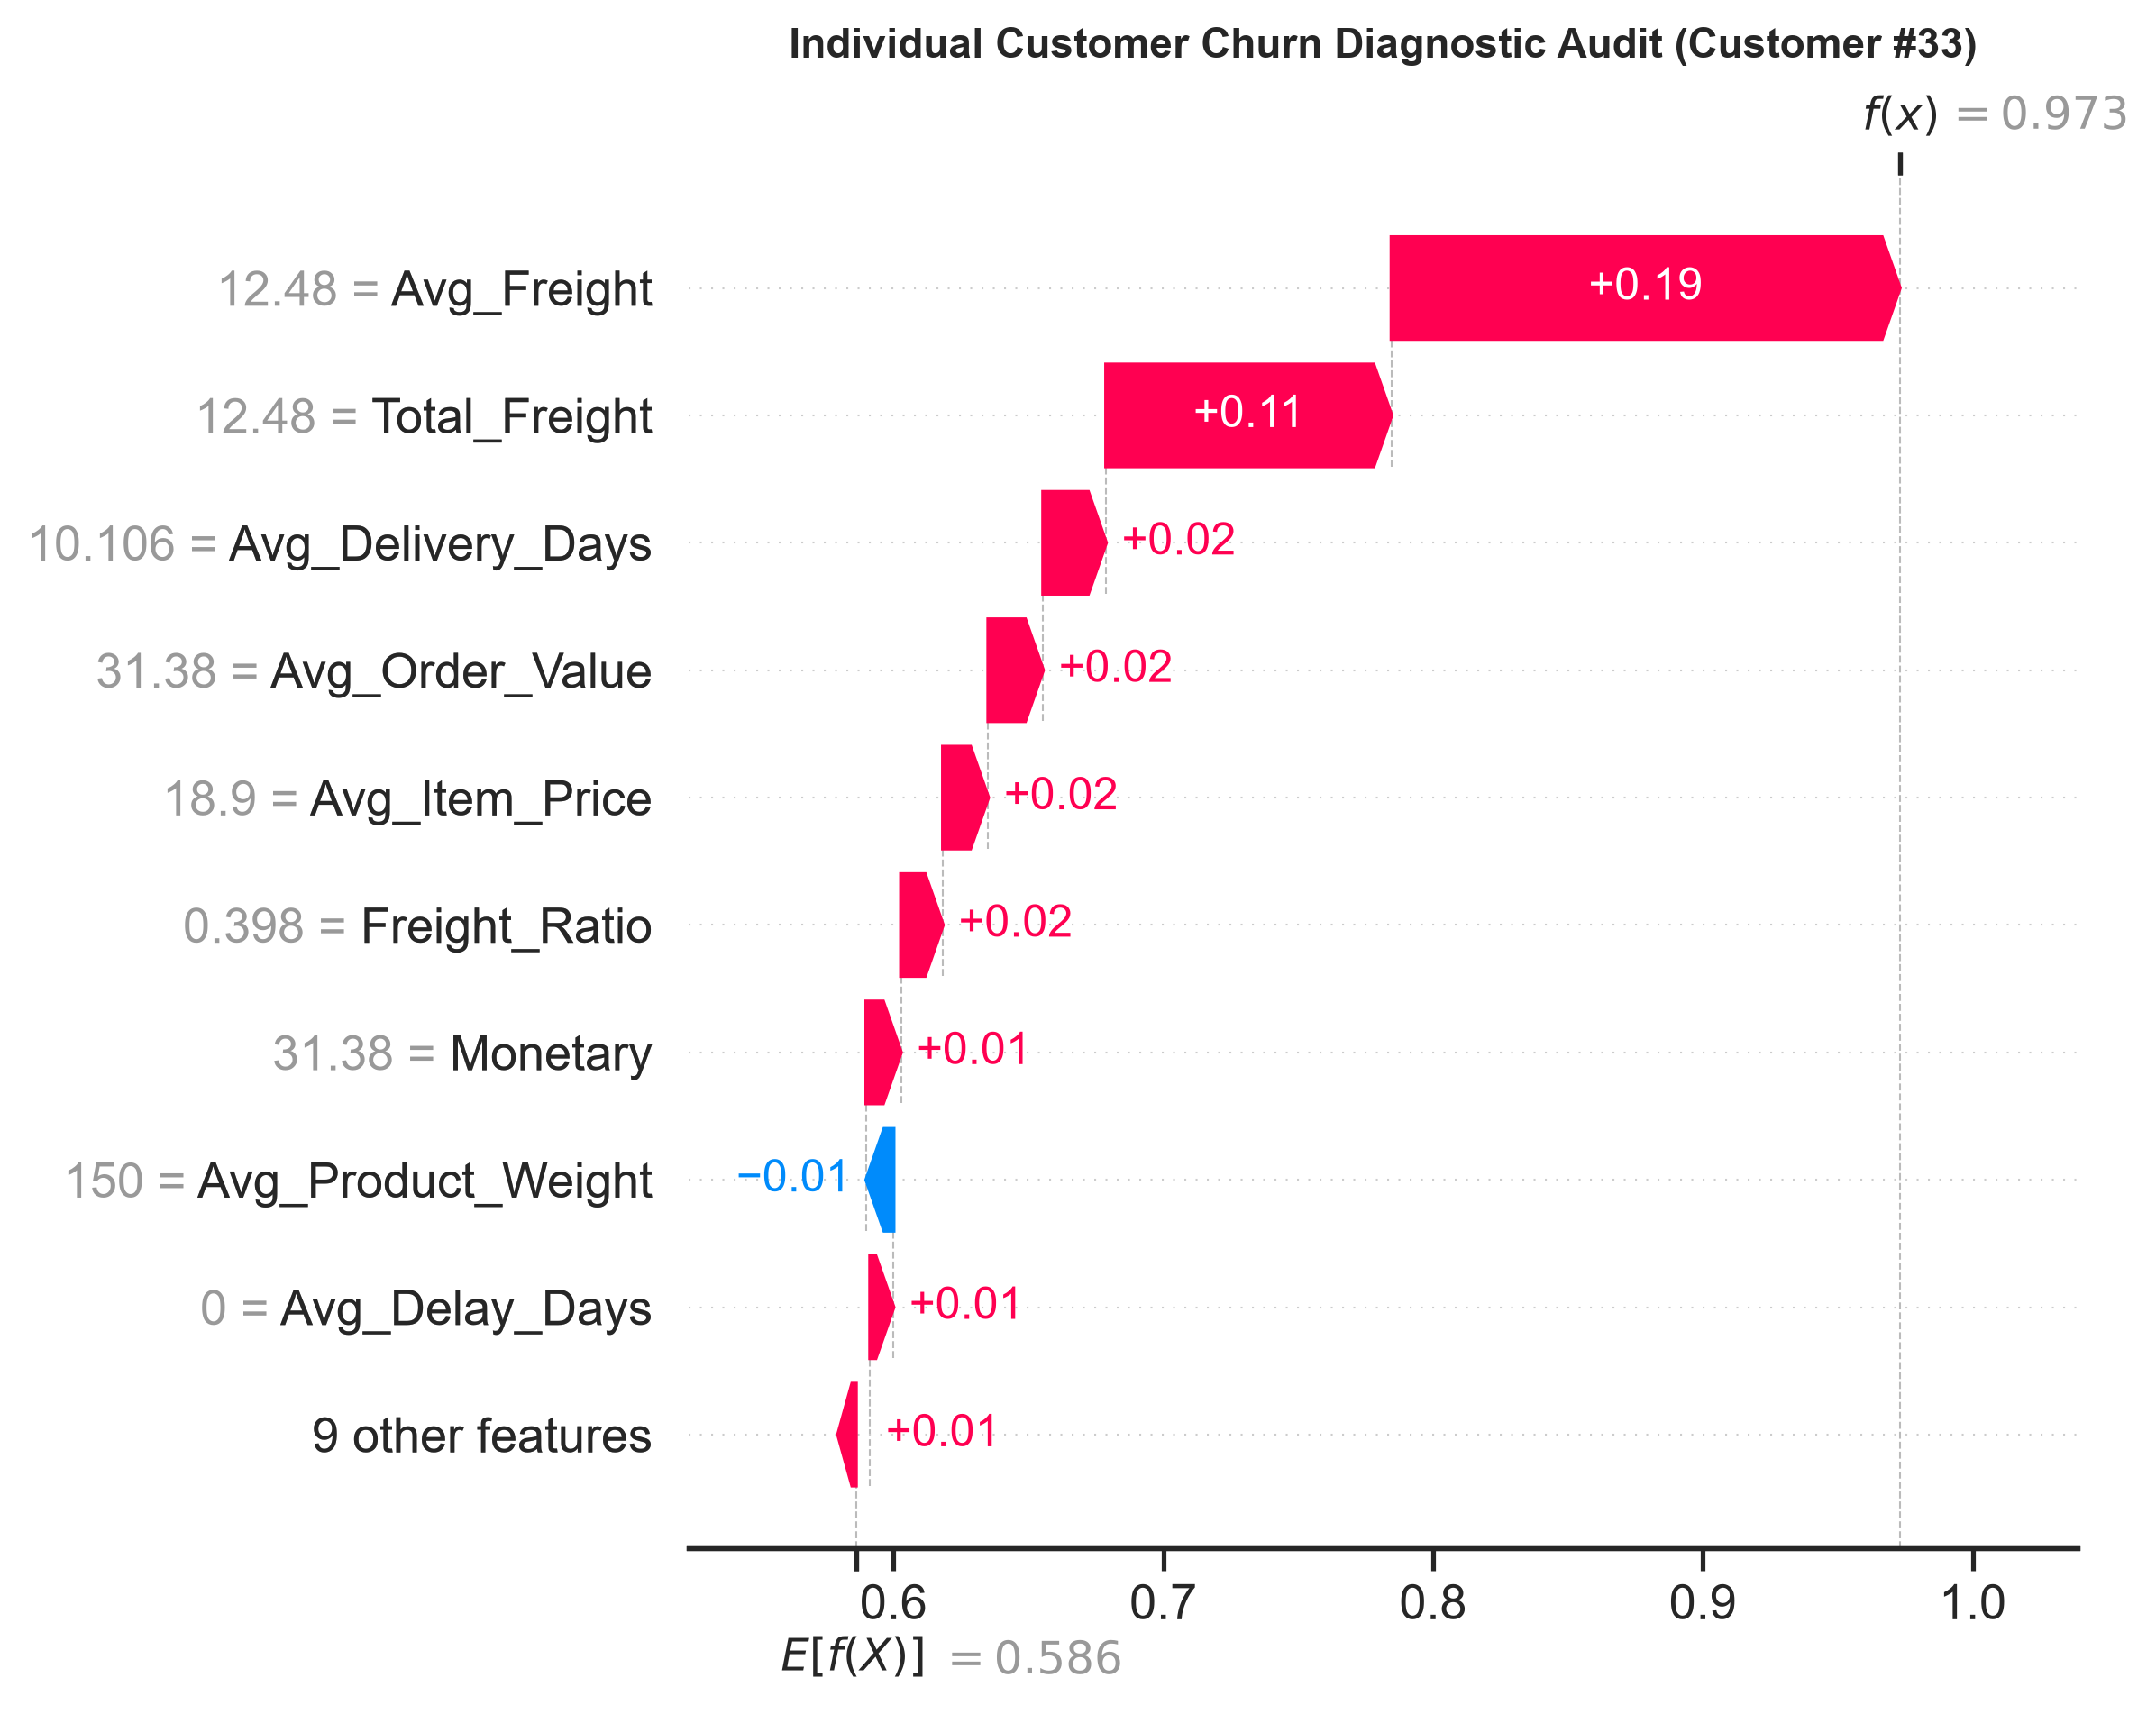

In [5]:
# Compute SHAP values on Random Forest
X_shap_sample = X_test.sample(1500, random_state=42)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_shap_sample)

# In binary classification, slice for positive class (Churned = 1)
shap_values_churn = shap_values[:, :, 1]

# 1. Beeswarm Summary Plot
plt.figure(figsize=(10, 7.5), dpi=300)
shap.plots.beeswarm(shap_values_churn, max_display=12, show=False)
plt.title("SHAP Summary Beeswarm Plot: Multi-Dimensional Churn Drivers", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 2. Individual Customer Waterfall Plot Case Study
y_test_probs = rf_model.predict_proba(X_test)[:, 1]
at_risk_idx = np.where(y_test_probs > 0.85)[0][5]
sample_row = X_test.iloc[at_risk_idx:at_risk_idx+1]
shap_single = explainer(sample_row)

plt.figure(figsize=(9, 6), dpi=300)
shap.plots.waterfall(shap_single[0, :, 1], max_display=10, show=False)
plt.title(f"Individual Customer Churn Diagnostic Audit (Customer #{at_risk_idx})", fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

## 6. Prescriptive Retention Strategy Decision Matrix

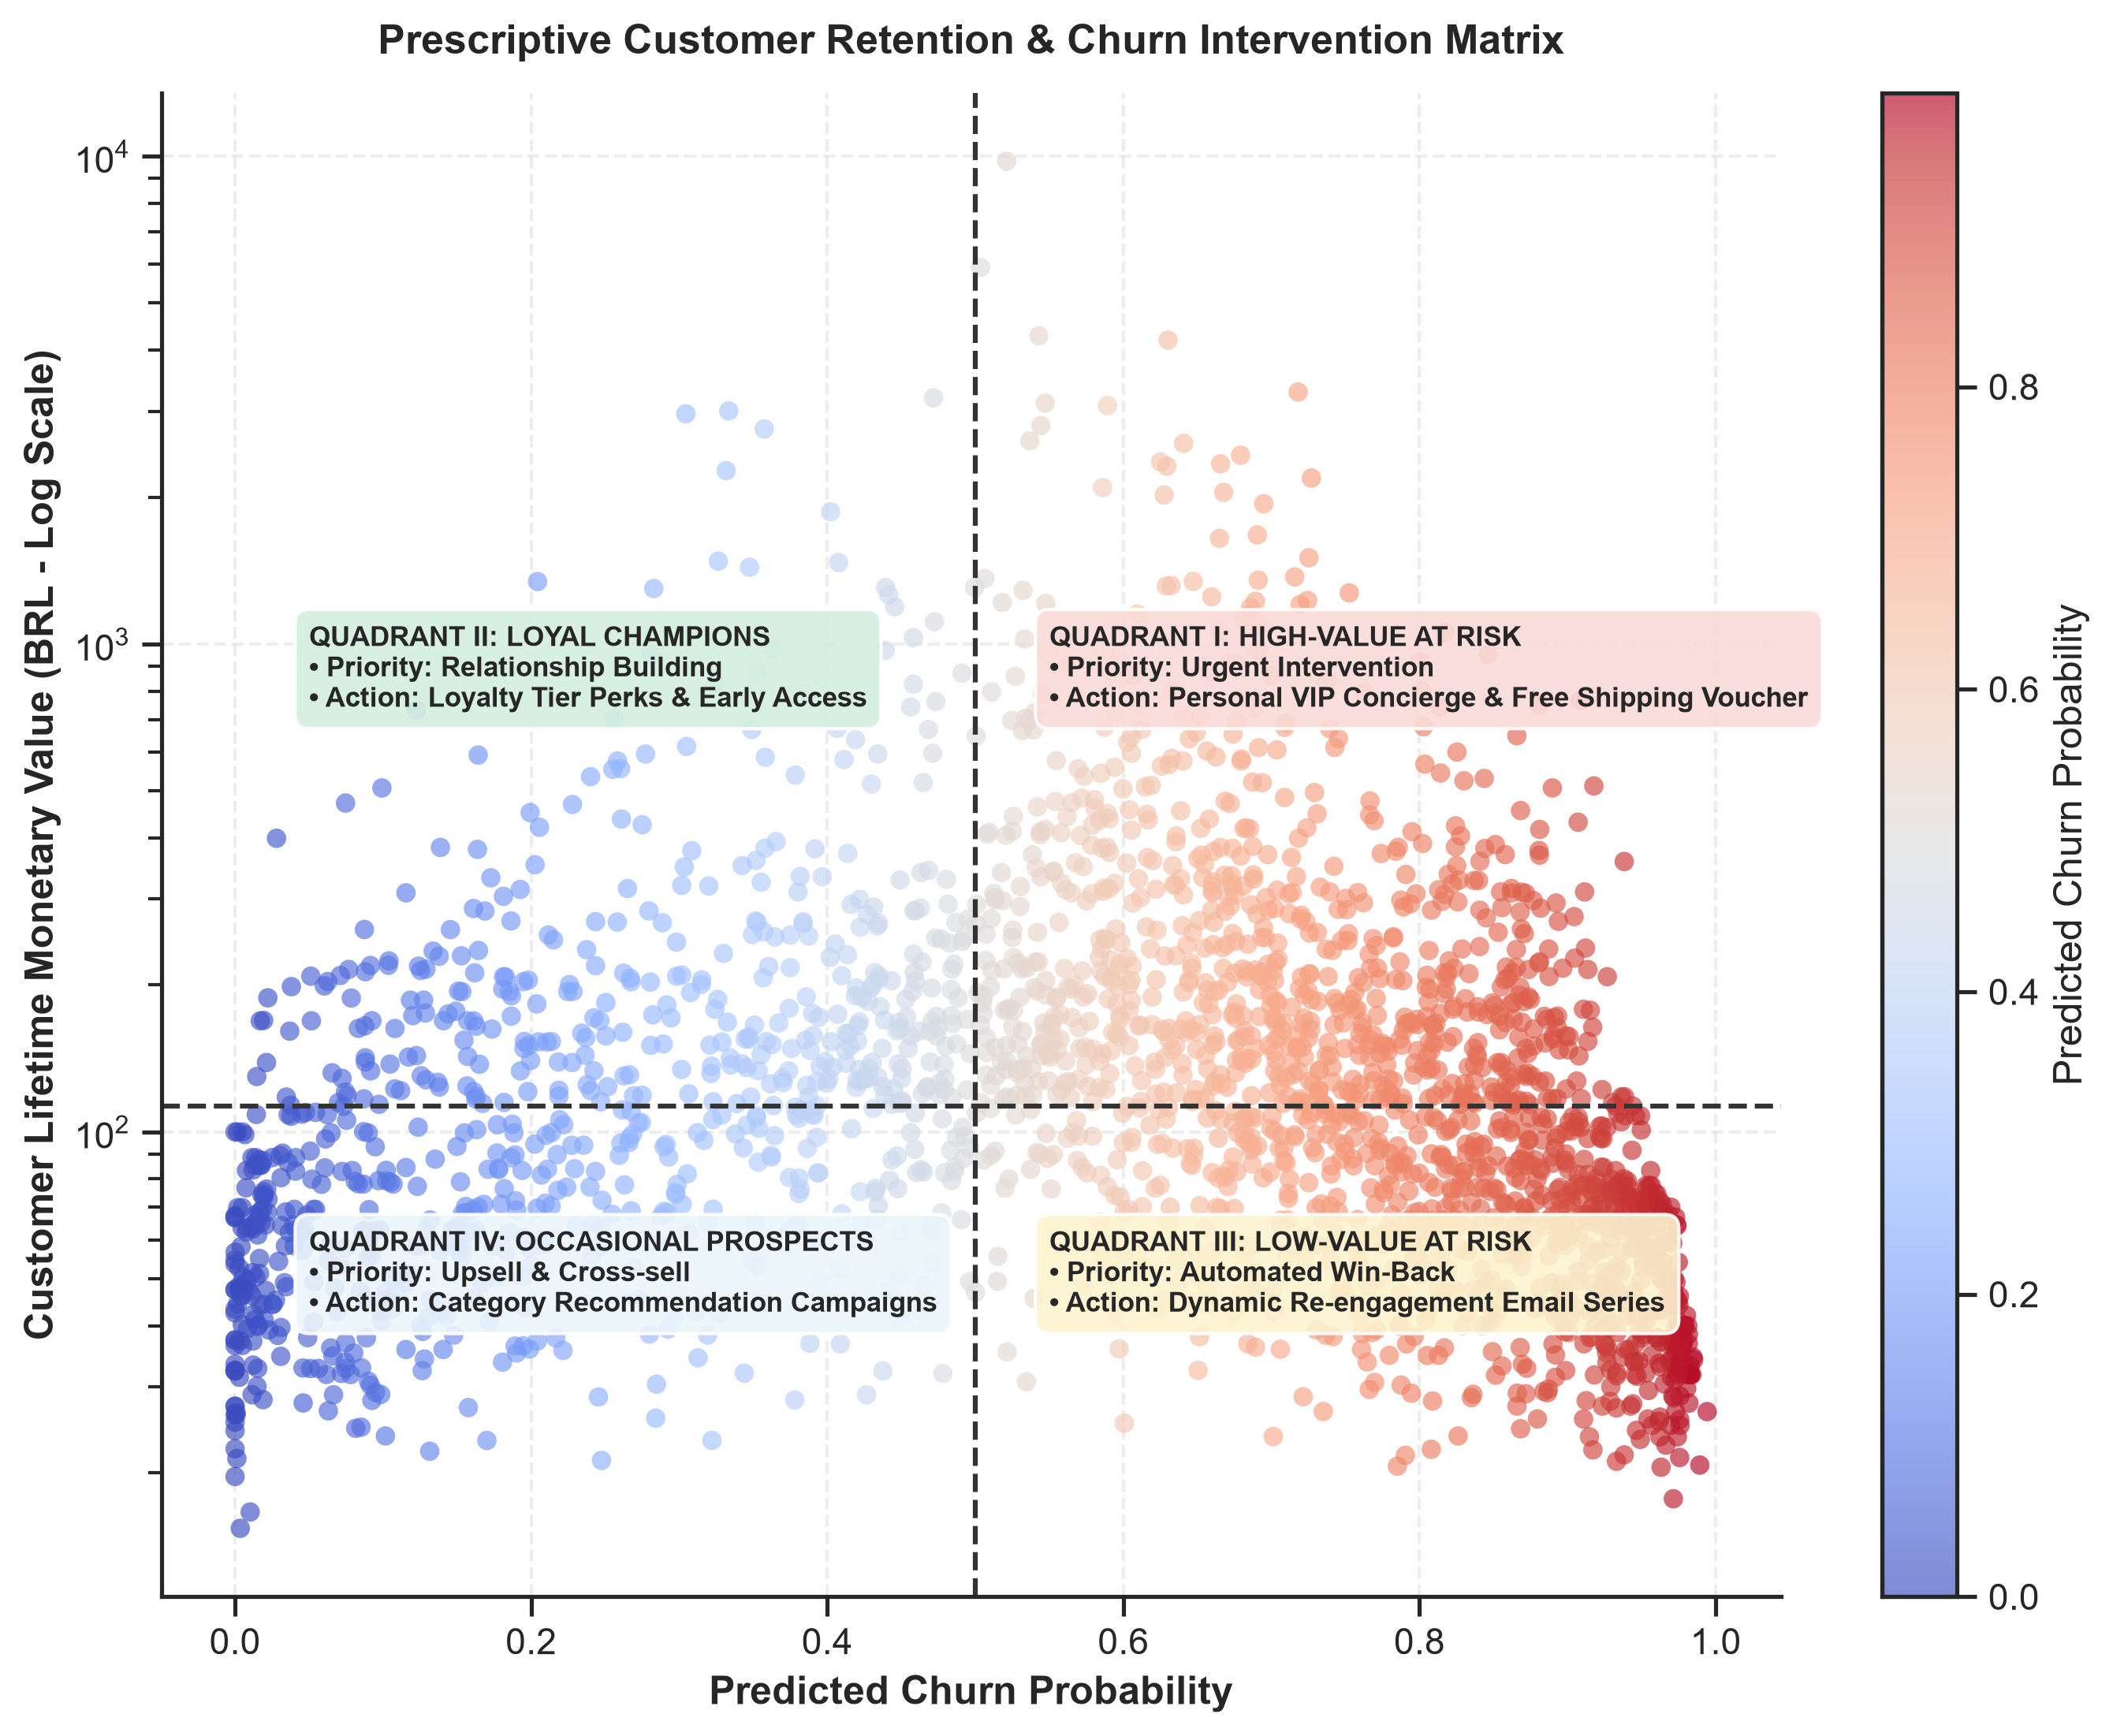

In [6]:
plt.figure(figsize=(9.5, 7.5), dpi=300)
sample_idx = np.random.RandomState(42).choice(len(X_test), 2500, replace=False)
sample_spend = X_test["Monetary"].iloc[sample_idx]
sample_risk = y_test_probs[sample_idx]
median_spend = X_test["Monetary"].median()

scatter = plt.scatter(
    sample_risk,
    sample_spend,
    c=sample_risk,
    cmap="coolwarm",
    alpha=0.65,
    s=35,
    edgecolor="none"
)
plt.colorbar(scatter, label="Predicted Churn Probability")

plt.axvline(0.50, color="#333333", linestyle="--", linewidth=1.5)
plt.axhline(median_spend, color="#333333", linestyle="--", linewidth=1.5)

plt.text(0.55, sample_spend.quantile(0.96), "QUADRANT I: HIGH-VALUE AT RISK\n• Priority: Urgent Intervention\n• Action: Personal VIP Concierge & Free Shipping Voucher",
         fontsize=8.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.5", facecolor="#FADBD8", alpha=0.90))

plt.text(0.05, sample_spend.quantile(0.96), "QUADRANT II: LOYAL CHAMPIONS\n• Priority: Relationship Building\n• Action: Loyalty Tier Perks & Early Access",
         fontsize=8.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.5", facecolor="#D4EFDF", alpha=0.90))

plt.text(0.55, sample_spend.quantile(0.12), "QUADRANT III: LOW-VALUE AT RISK\n• Priority: Automated Win-Back\n• Action: Dynamic Re-engagement Email Series",
         fontsize=8.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.5", facecolor="#FCF3CF", alpha=0.90))

plt.text(0.05, sample_spend.quantile(0.12), "QUADRANT IV: OCCASIONAL PROSPECTS\n• Priority: Upsell & Cross-sell\n• Action: Category Recommendation Campaigns",
         fontsize=8.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.5", facecolor="#EBF5FB", alpha=0.90))

plt.yscale("log")
plt.title("Prescriptive Customer Retention & Churn Intervention Matrix", fontsize=12.5, fontweight="bold", pad=12)
plt.xlabel("Predicted Churn Probability", fontweight="bold")
plt.ylabel("Customer Lifetime Monetary Value (BRL - Log Scale)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.35)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()